In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
!pip install prophet
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, RandomizedSearchCV, cross_validate, KFold
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LinearRegression

# Model evaluation

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, confusion_matrix


# Pipeline
from sklearn.pipeline import Pipeline

# Explainable AI
import shap

In [9]:
# Load datatrain
df = pd.read_csv('/content/sales_data_sample.csv', encoding='latin-1')  # or 'cp1252', 'ISO-8859-1', etc.
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl7m0mswy/1a85lw2a.json



Columns: Index(['ordernumber', 'quantityordered', 'priceeach', 'orderlinenumber',
       'sales', 'orderdate', 'status', 'qtr_id', 'month_id', 'year_id',
       'productline', 'msrp', 'productcode', 'customername', 'phone',
       'addressline1', 'addressline2', 'city', 'state', 'postalcode',
       'country', 'territory', 'contactlastname', 'contactfirstname',
       'dealsize'],
      dtype='object')


DEBUG:cmdstanpy:input tempfile: /tmp/tmpl7m0mswy/q9f0_952.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68748', 'data', 'file=/tmp/tmpl7m0mswy/1a85lw2a.json', 'init=/tmp/tmpl7m0mswy/q9f0_952.json', 'output', 'file=/tmp/tmpl7m0mswy/prophet_model_hwxu0ne/prophet_model-20250430174833.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:48:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:48:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


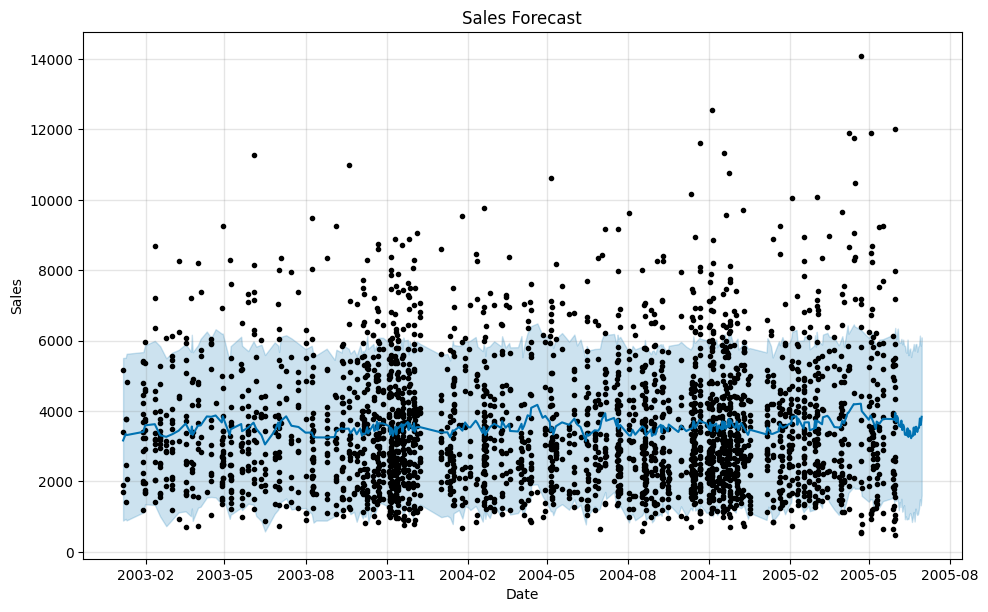

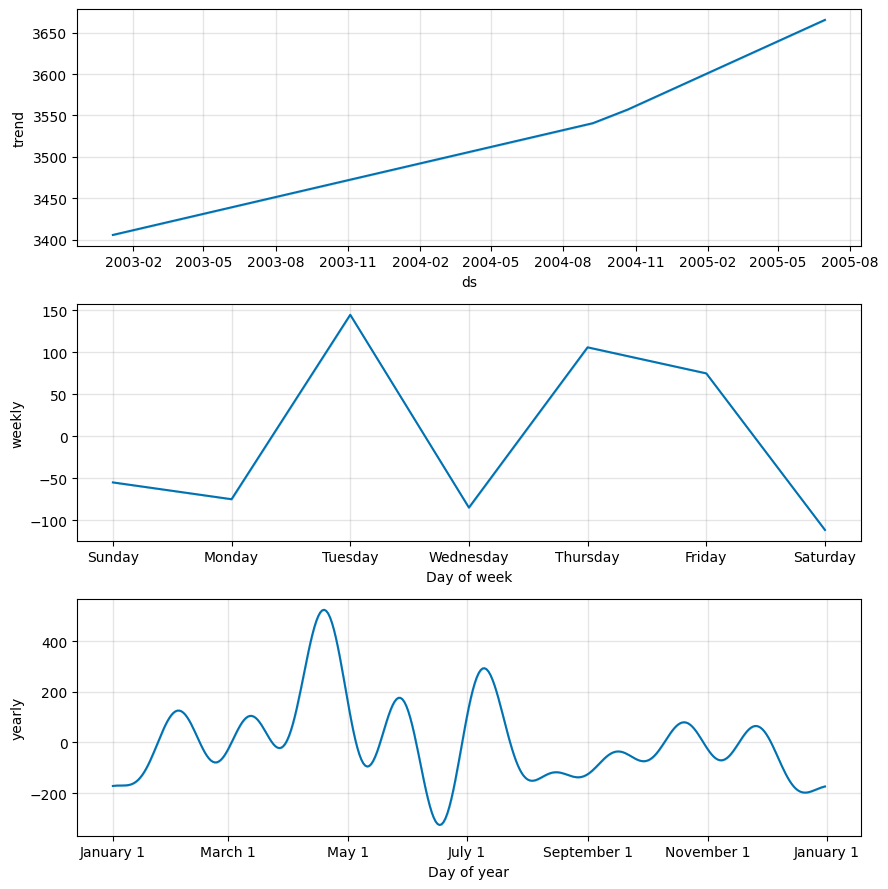

In [13]:

df.columns = [col.strip().lower() for col in df.columns]
print("\nColumns:", df.columns)


df_prophet = df[['orderdate', 'sales']].copy()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])


from prophet import Prophet
model = Prophet()
model.fit(df_prophet)


future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)


fig1 = model.plot(forecast)
plt.title('Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


fig2 = model.plot_components(forecast)
plt.show()


df_prophet['day_num'] = (df_prophet['ds'] - df_prophet['ds'].min()).dt.days
X = df_prophet[['day_num']]
y = df_prophet['y']

lr = LinearRegression()
lr.fit(X, y)
df_prophet['trend'] = lr.predict(X)




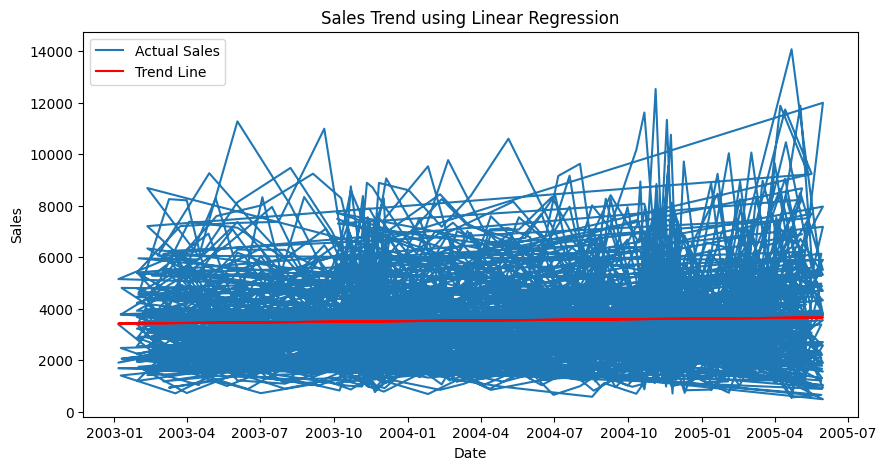

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual Sales')
plt.plot(df_prophet['ds'], df_prophet['trend'], color='red', label='Trend Line')
plt.title('Sales Trend using Linear Regression')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()